In [46]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm
from torch import nn
import seaborn as sns

import common
importlib.reload(common)
from common import (
    load_swiss_roll, TinyMLP, Residual,
    cosine_beta_schedule, extract,
    train as train_loop, load_or_train, load_checkpoint,
    generate_samples_euler, generate_samples_ode, generate_samples_ddpm,
)

%matplotlib inline

torch.Size([10000, 2])


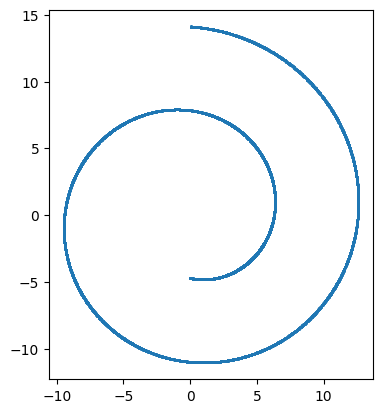

Data range: x=[-1.74, 1.60]
Data range: y=[-1.61, 2.01]


In [2]:
train_set, swiss_roll = load_swiss_roll(n_samples=10000, noise=0)
print(train_set.shape)
plt.axes().set_aspect('equal')
plt.scatter(swiss_roll[:, 0], swiss_roll[:, 1], s=1)
plt.show()

print(f"Data range: x=[{train_set[:,0].min():.2f}, {train_set[:,0].max():.2f}]")
print(f"Data range: y=[{train_set[:,1].min():.2f}, {train_set[:,1].max():.2f}]")

In [3]:
# TOY PROBLEM FROM "Back to Basics: Let Denoising Generative Models Denoise"
def random_projection_matrix(D, seed=None):
    rng = np.random.default_rng(seed)
    
    # Start with random Gaussian matrix (D x 2)
    G = rng.normal(size=(D, 2))
    
    # QR decomposition
    Q, _ = np.linalg.qr(G)  # Q has orthonormal columns (D x 2)
    
    # Transpose to get (2 x D)
    A = Q.T
    
    return A

r_bury =  random_projection_matrix(100, seed=42)
buried_train_set = train_set @ r_bury
back_train_set = buried_train_set @ r_bury.T

diff = np.linalg.norm(train_set - back_train_set, axis=1)
print(buried_train_set.shape)
print(np.max(diff))

torch.Size([10000, 100])
1.807312143953211e-15


/tmp/ipykernel_6138/3583821340.py:17: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  buried_train_set = train_set @ r_bury
/tmp/ipykernel_6138/3583821340.py:18: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  back_train_set = buried_train_set @ r_bury.T


In [ ]:
# Flow Matching for Generative Modeling
# https://arxiv.org/abs/2210.02747
from pathlib import Path
import torch.nn.functional as F


def sample_t(batch_size, eps=0.05):
    """Sample t between eps and 1-eps."""
    # return torch.rand(batch_size)[:,None] / (1-eps) + eps
    return (torch.rand(batch_size)[:, None] * (1 - 2*eps)) + eps

# MAYBE THIS IS THE SOURCE OF DIFF BETWEEN MEANFLOW AND FLOW MATCHING (in my experiments)
def sample_t_r_lognormal(batch_size, device, mu=-0.4, sigma=1.0, flow_ratio=0.5):
    """Sigmoid(N(mu, sigma)) pairs; randomly collapse a fraction to r=t."""
    n = torch.randn(batch_size, 2, device=device) * sigma + mu
    s = torch.sigmoid(n)
    t = s.max(dim=1).values[:, None]
    r = s.min(dim=1).values[:, None]
    if flow_ratio > 0:
        mask = torch.rand(batch_size, 1, device=device) < flow_ratio
        r = torch.where(mask, t, r)
    return t, r


def train_step_fm_vpred(x, net, optimizer):
    """Flow Matching — velocity prediction.
    The path from noise to data is a straight line, so the target
    velocity is simply v = e - x (constant along the path).
    """
    t = sample_t(len(x), eps=0).to(x.device)
    e = torch.randn_like(x)

    # ot assignment (exact or Sinkhorn) can help, but is not essential for learning a good generative model.
    # idx = sinkhorn_assign(x, e)
    # e = e[idx]

    # Convention: t=0 -> z=x (data), t=1 -> z=e (noise)
    z = (1-t) * x + t * e
    v_pred = net(z, t)
    v_target = e - x
    loss = F.mse_loss(v_pred, v_target)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss


def train_step_fm_xpred(x, net, optimizer):
    """Flow Matching — x prediction (net internally converts to velocity).
    https://arxiv.org/pdf/2511.13720 Back to basics, Let Denoising Generative Models denoise
    # x_theta = net_theta(z_t, t)
    # zt = (1-t) x_theta + t * eps_theta
    # v_theta = eps_theta - x_theta
    # eps_theta = (zt- (1-t) x_theta) / t
    # v_theta_true = (zt-x_theta)/t
    net.x_prediction=True so forward already returns (z - x_pred) / t.
    """
    t = sample_t(len(x), eps=5e-2).to(x.device)
    e = torch.randn_like(x)

    if net.reverse_time:
        z = t * x + (1-t) * e
    else:
        z = (1-t) * x + t * e
    v_pred = net(z, t)       # net converts x_pred -> v internally

    if net.reverse_time:
        v_target = (x - z) / (1 - t)
    else:
        v_target = (z - x) / t  # equivalent to e - x, but expressed in x-pred form

    loss = ((v_pred - v_target)**2).mean()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss


# DDPM cosine schedule (used by train_step_ddpm below)
T_DDPM = 1000
_betas = cosine_beta_schedule(T_DDPM)
_alphas_cumprod = torch.cumprod(1. - _betas, dim=0)
_sqrt_ac = torch.sqrt(_alphas_cumprod)
_sqrt_1m_ac = torch.sqrt(1. - _alphas_cumprod)


def q_sample_ddpm(x_start, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x_start)
    return extract(_sqrt_ac, t, x_start.shape) * x_start \
         + extract(_sqrt_1m_ac, t, x_start.shape) * noise


def train_step_ddpm(x, net, optimizer):
    """DDPM — noise prediction with cosine cumulative-alpha schedule.
    Uses discrete timesteps t in {0,...,T-1} and the standard
    DDPM forward process q(x_t | x_0) = N(sqrt(ac_t)*x, (1-ac_t)*I).
    """
    t = torch.randint(0, T_DDPM, (len(x),), device=x.device)
    noise = torch.randn_like(x)
    x_noisy = q_sample_ddpm(x, t, noise)
    t_float = (t.float() / T_DDPM).unsqueeze(1)
    noise_pred = net(x_noisy, t_float)
    loss = F.mse_loss(noise_pred, noise)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss

[2, 8, 64, 128]
[[-0.37621415 -0.92653275]
 [-0.92653275  0.37621415]]


/tmp/ipykernel_6138/2720503524.py:19: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  buried = train_set @ projection_matrices[0]


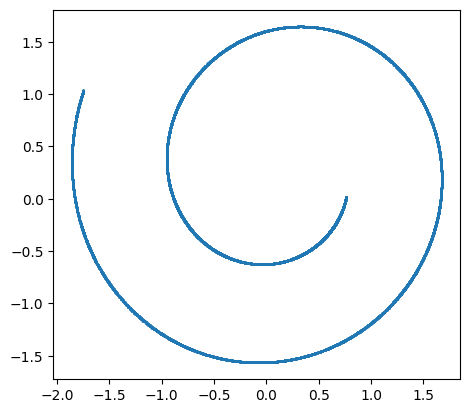

In [59]:
# bury data into [2, 8, 64, 128] dimensions and train a model on it
def load_or_make(d_dims=[2, 8, 64, 128], seed=42):
    """Load or create random projection matrices for given dimensions."""
    checkpoint_path = Path("checkpoints/projection_matrices.npz")
    if checkpoint_path.exists():
        data = np.load(checkpoint_path)
        projection_matrices = [data[f'arr_{i}'] for i in range(len(d_dims))]
    else:
        projection_matrices = [random_projection_matrix(d_dim, seed=seed).astype(np.float32) for d_dim in d_dims]
        np.savez(checkpoint_path, *projection_matrices)
    return projection_matrices
   
projection_matrices = load_or_make(d_dims=[2, 8, 64, 128], seed=42)
d_dims = [v.shape[1] for v in projection_matrices]
print(d_dims)
print(projection_matrices[0])

# plot the first 2 dimensions of the buried data
buried = train_set @ projection_matrices[0]
plt.axes().set_aspect('equal')
plt.scatter(buried[:, 0], buried[:, 1], s=1)
plt.show()


/tmp/ipykernel_6138/1193795895.py:13: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  buried_train_set = train_set @ projection_matrices[i]


torch.Size([10000, 2])


loss = 1.353535: 100%|███████████████████████████████████████| 10000/10000 [00:25<00:00, 399.73it/s]


Saved bury_toy_problem_2_flow_matching_vpred to checkpoints/bury_toy_problem_2_flow_matching_vpred.pt


loss = 1.410181: 100%|███████████████████████████████████████| 10000/10000 [00:27<00:00, 366.70it/s]


Saved bury_toy_problem_2_flow_matching_xpred_revtime to checkpoints/bury_toy_problem_2_flow_matching_xpred_revtime.pt


loss = 0.425162: 100%|███████████████████████████████████████| 10000/10000 [00:27<00:00, 362.17it/s]


Saved bury_toy_problem_2_flow_matching_ddpm to checkpoints/bury_toy_problem_2_flow_matching_ddpm.pt


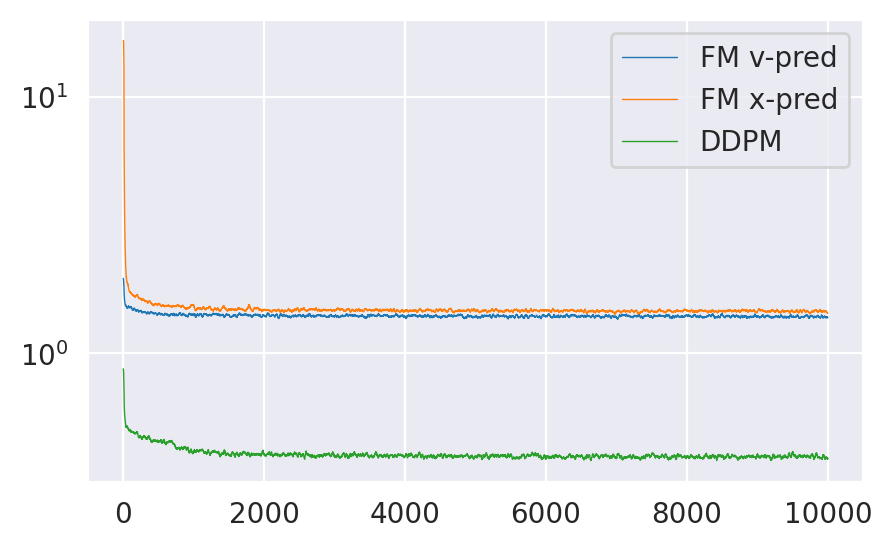

torch.Size([10000, 8])


loss = 0.339319: 100%|███████████████████████████████████████| 10000/10000 [00:25<00:00, 396.09it/s]


Saved bury_toy_problem_8_flow_matching_vpred to checkpoints/bury_toy_problem_8_flow_matching_vpred.pt


loss = 0.361824: 100%|███████████████████████████████████████| 10000/10000 [00:28<00:00, 356.50it/s]


Saved bury_toy_problem_8_flow_matching_xpred_revtime to checkpoints/bury_toy_problem_8_flow_matching_xpred_revtime.pt


loss = 0.103891:  95%|██████████████████████████████████████  | 9502/10000 [00:26<00:01, 359.91it/s]

In [ ]:
# ── Checkpointing ─────────────────────────────────────────────────────────────
LOAD_FROM_CHECKPOINT_IF_AVAILABLE = True
SAVE_CHECKPOINT_AFTER_TRAIN = True
ckpt_dir = Path("checkpoints")
ckpt_dir.mkdir(parents=True, exist_ok=True)
niter = 10000
lr = 1e-3
time_dim = 0  # Set to 64 to use sinusoidal time embedding
h_dim = 128

for i, d_dim in enumerate(d_dims):

    buried_train_set = train_set @ projection_matrices[i]

    print(buried_train_set.shape)

    _kw = dict(data=buried_train_set, niter=niter, lr=1e-3, ckpt_dir=ckpt_dir,
            load=LOAD_FROM_CHECKPOINT_IF_AVAILABLE, save=SAVE_CHECKPOINT_AFTER_TRAIN)

    model_v_pred = TinyMLP(d_dim, h_dim, time_dim=time_dim, x_prediction=False)
    model_x_pred = TinyMLP(d_dim, h_dim, time_dim=time_dim, x_prediction=True, reverse_time=True)
    model_ddpm   = TinyMLP(d_dim, h_dim, time_dim=32,       x_prediction=False)

    losses_v_pred = load_or_train(model_v_pred, f"bury_toy_problem_{d_dim}_flow_matching_vpred", train_step_fm_vpred, **_kw)
    losses_x_pred = load_or_train(model_x_pred, f"bury_toy_problem_{d_dim}_flow_matching_xpred_revtime", train_step_fm_xpred, **_kw)
    losses_ddpm   = load_or_train(model_ddpm,   f"bury_toy_problem_{d_dim}_flow_matching_ddpm",  train_step_ddpm,     **_kw)

    with sns.axes_style("darkgrid"):
        fig, ax = plt.subplots(1,1, figsize=(5, 3), dpi=200)
        ax.semilogy(np.arange(len(losses_v_pred)), losses_v_pred, linewidth=0.5, label='FM v-pred')
        ax.semilogy(np.arange(len(losses_x_pred)), losses_x_pred, linewidth=0.5, label='FM x-pred')
        ax.semilogy(np.arange(len(losses_ddpm)),   losses_ddpm,   linewidth=0.5, label='DDPM')
        plt.legend()
        plt.show()


=== Inference in dimension 2 ===
Loaded bury_toy_problem_2_flow_matching_vpred from checkpoints/bury_toy_problem_2_flow_matching_vpred.pt
Loaded bury_toy_problem_2_flow_matching_xpred_revtime from checkpoints/bury_toy_problem_2_flow_matching_xpred_revtime.pt
Loaded bury_toy_problem_2_flow_matching_ddpm from checkpoints/bury_toy_problem_2_flow_matching_ddpm.pt
torch.Size([10000, 2]) (2, 2)


/tmp/ipykernel_6138/3838088143.py:39: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  samples_euler_2d       = samples_euler @ AT
/tmp/ipykernel_6138/3838088143.py:40: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  samples_euler_xpred_2d = samples_euler_xpred @ AT
/tmp/ipykernel_6138/3838088143.py:41: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  samples_ddpm_2d        = samples_ddpm @ AT



=== Inference in dimension 8 ===
Loaded bury_toy_problem_8_flow_matching_vpred from checkpoints/bury_toy_problem_8_flow_matching_vpred.pt
Loaded bury_toy_problem_8_flow_matching_xpred_revtime from checkpoints/bury_toy_problem_8_flow_matching_xpred_revtime.pt
Loaded bury_toy_problem_8_flow_matching_ddpm from checkpoints/bury_toy_problem_8_flow_matching_ddpm.pt
torch.Size([10000, 8]) (8, 2)

=== Inference in dimension 64 ===
Loaded bury_toy_problem_64_flow_matching_vpred from checkpoints/bury_toy_problem_64_flow_matching_vpred.pt
Loaded bury_toy_problem_64_flow_matching_xpred_revtime from checkpoints/bury_toy_problem_64_flow_matching_xpred_revtime.pt
Loaded bury_toy_problem_64_flow_matching_ddpm from checkpoints/bury_toy_problem_64_flow_matching_ddpm.pt
torch.Size([10000, 64]) (64, 2)

=== Inference in dimension 512 ===
Loaded bury_toy_problem_512_flow_matching_vpred from checkpoints/bury_toy_problem_512_flow_matching_vpred.pt
Loaded bury_toy_problem_512_flow_matching_xpred_revtime from

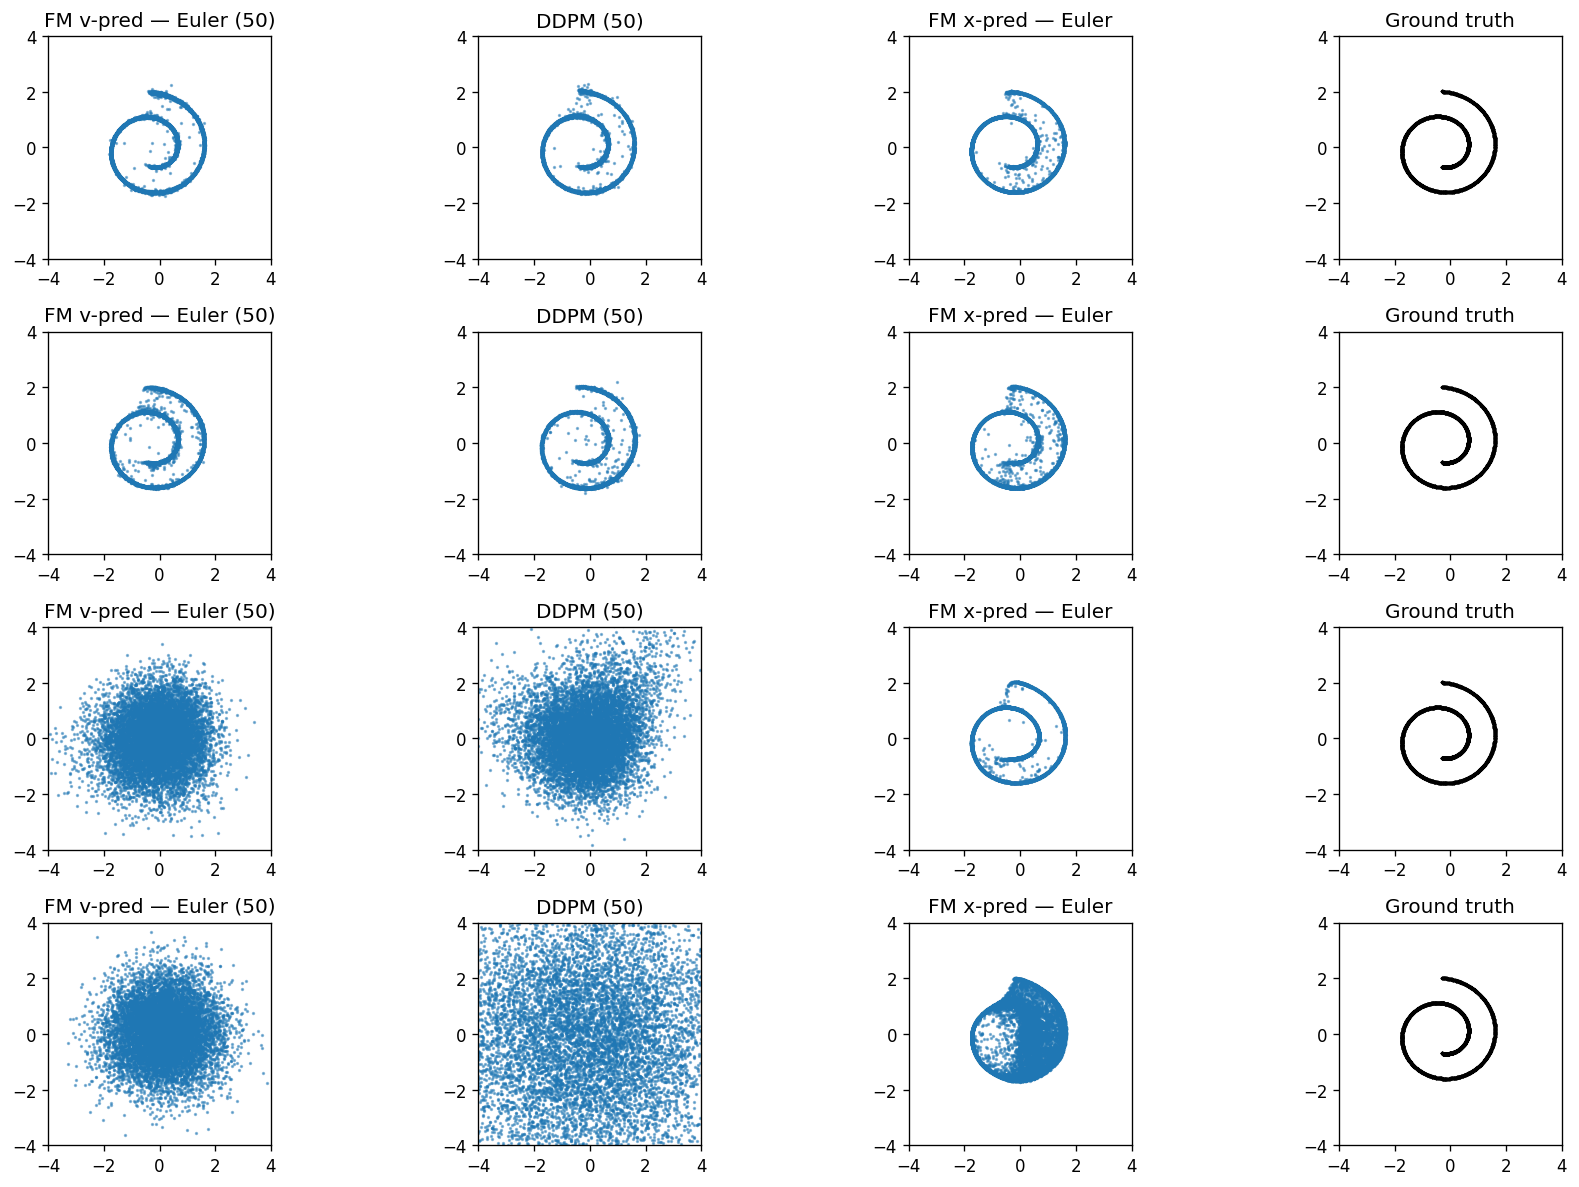

In [ ]:
from common_viz import animate_flow

n_steps_ddpm = 50
n_steps_euler = 50

sc_kw = dict(alpha=0.5, s=1)
gt = train_set.cpu().numpy()



# ---- Plot ----
fig, axes = plt.subplots(len(d_dims), 4, figsize=(15, 10), dpi=120)
axes = axes.reshape(len(d_dims), 4)

for i, d_dim in enumerate(d_dims):

    print(f"\n=== Inference in dimension {d_dim} ===")

    # Load projection matrix
    A = projection_matrices[i]              # (2, D)
    AT = A.T                                # (D, 2)

    model_v_pred = TinyMLP(d_dim, h_dim, time_dim=time_dim, x_prediction=False)
    model_x_pred = TinyMLP(d_dim, h_dim, time_dim=time_dim, x_prediction=True, reverse_time=True)
    model_ddpm   = TinyMLP(d_dim, h_dim, time_dim=32, x_prediction=False)

    load_or_train(model_v_pred, f"bury_toy_problem_{d_dim}_flow_matching_vpred", train_step_fm_vpred, **_kw)
    load_or_train(model_x_pred, f"bury_toy_problem_{d_dim}_flow_matching_xpred_revtime", train_step_fm_xpred, **_kw)
    load_or_train(model_ddpm,   f"bury_toy_problem_{d_dim}_flow_matching_ddpm",  train_step_ddpm,     **_kw)

    # ---- Sampling in D-dim ----
    samples_euler       = generate_samples_euler(model_v_pred, d_dim=d_dim, n_samples=10000, n_steps=n_steps_euler)
    samples_euler_xpred = generate_samples_euler(model_x_pred, d_dim=d_dim, n_samples=10000, n_steps=n_steps_euler)
    samples_ddpm        = generate_samples_ddpm(model_ddpm, _betas, _alphas_cumprod, d_dim=d_dim, n_samples=10000, n_steps=n_steps_ddpm)

    print(samples_euler.shape, AT.shape)
    # ---- Decode back to 2D ----
    samples_euler_2d       = samples_euler @ AT
    samples_euler_xpred_2d = samples_euler_xpred @ AT
    samples_ddpm_2d        = samples_ddpm @ AT

    axes[i, 0].scatter(samples_euler_2d[:, 0], samples_euler_2d[:, 1], **sc_kw)
    axes[i, 0].set_title(f'FM v-pred — Euler ({n_steps_euler}) - dim={d_dim}')

    axes[i, 1].scatter(samples_ddpm_2d[:, 0], samples_ddpm_2d[:, 1], **sc_kw)
    axes[i, 1].set_title(f'DDPM ({n_steps_ddpm}) - dim={d_dim}')

    axes[i, 2].scatter(samples_euler_xpred_2d[:, 0], samples_euler_xpred_2d[:, 1], **sc_kw)
    axes[i, 2].set_title(f'FM x-pred — Euler ({n_steps_euler}) - dim={d_dim}')
    axes[i, 3].scatter(gt[:, 0], gt[:, 1], c='black', s=1, alpha=0.3)
    axes[i, 3].set_title('Ground truth')

    for ax in axes.flat:
        ax.set_aspect('equal')
        ax.set_xlim(-4, 4)
        ax.set_ylim(-4, 4)

plt.tight_layout()
plt.show()